In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
from pathlib import Path

RAW_DIR      = Path('/import/home2/share/byual/MouseKidneyInjuryXenium_NC2025_Qiao')
PROCESSED    = Path('data/processed')
PROCESSED.mkdir(parents=True, exist_ok=True)

In [2]:
adata = sc.read_h5ad(RAW_DIR / "Xenium.h5ad")
adata

AnnData object with n_obs × n_vars = 1374915 × 299
    obs: 'x_centroid', 'y_centroid', 'n_genes', 'n_counts', 'ident', 'region', 'celltype_plot', 'time', 'CN'
    uns: 'CN_colors', 'celltype_plot_colors', 'ident_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
time_to_days = {
    'Sham': 0,
    'Hour4': 4/24,
    'Hour12': 12/24,
    'Day2': 2,
    'Day14': 14,
    'Week6': 42
}
adata.obs['injury_time_days'] = np.array(adata.obs['time'].map(time_to_days))

In [4]:
ALL_CELLTYPES = adata.obs['celltype_plot'].unique().tolist()

In [5]:
def safe_name(celltype: str) -> str:
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in celltype)

def extract_celltype_files(
    adata: sc.AnnData, processed_dir: Path = Path("data/processed"), celltypes: list[str] = ALL_CELLTYPES,
) -> None:
    processed_dir = Path(processed_dir)
    processed_dir.mkdir(parents=True, exist_ok=True)
    for ct in celltypes:
        out = processed_dir / f"{safe_name(ct)}.h5ad"
        if out.exists():
            print(f"[extract] {ct!r}: exists, skipping ({out})")
            continue
        sub = adata[adata.obs["celltype_plot"].astype(str) == ct].copy()
        sub.write_h5ad(str(out), compression="gzip")

extract_celltype_files(adata)


[extract] 'PTS1': exists, skipping (data/processed/PTS1.h5ad)
[extract] 'Immune': exists, skipping (data/processed/Immune.h5ad)
[extract] 'EC': exists, skipping (data/processed/EC.h5ad)
[extract] 'PTS2': exists, skipping (data/processed/PTS2.h5ad)
[extract] 'DCT': exists, skipping (data/processed/DCT.h5ad)
[extract] 'Glom-EC': exists, skipping (data/processed/Glom-EC.h5ad)
[extract] 'Fib': exists, skipping (data/processed/Fib.h5ad)
[extract] 'ICB': exists, skipping (data/processed/ICB.h5ad)
[extract] 'CNT': exists, skipping (data/processed/CNT.h5ad)
[extract] 'ICA': exists, skipping (data/processed/ICA.h5ad)
[extract] 'Uro': exists, skipping (data/processed/Uro.h5ad)
[extract] 'TAL': exists, skipping (data/processed/TAL.h5ad)
[extract] 'PC': exists, skipping (data/processed/PC.h5ad)
[extract] 'Per-SMC': exists, skipping (data/processed/Per-SMC.h5ad)
[extract] 'Inj_PT': exists, skipping (data/processed/Inj_PT.h5ad)
[extract] 'Pod': exists, skipping (data/processed/Pod.h5ad)
[extract] 'F

In [6]:
adata.obs['celltype_plot'].unique().tolist()

['PTS1',
 'Immune',
 'EC',
 'PTS2',
 'DCT',
 'Glom-EC',
 'Fib',
 'ICB',
 'CNT',
 'ICA',
 'Uro',
 'TAL',
 'PC',
 'Per-SMC',
 'Inj_PT',
 'Pod',
 'FR_PT',
 'PEC',
 'PTS3',
 'DTL']

In [7]:
adata_prop = adata.copy()
adata_prop.obs['injury_time_days']

ShamL_1           0.0
ShamL_2           0.0
ShamL_3           0.0
ShamL_4           0.0
ShamL_5           0.0
                 ... 
Week6R_146821    42.0
Week6R_147127    42.0
Week6R_147130    42.0
Week6R_147467    42.0
Week6R_147490    42.0
Name: injury_time_days, Length: 1374915, dtype: float64

In [8]:
adata_prop.obs['ident'].unique()

['ShamL', 'ShamR', 'Hour4L', 'Hour4R', 'Hour12L', ..., 'Day2R', 'Day14L', 'Day14R', 'Week6L', 'Week6R']
Length: 12
Categories (12, object): ['ShamL', 'ShamR', 'Hour4L', 'Hour4R', ..., 'Day14L', 'Day14R', 'Week6L', 'Week6R']

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = adata_prop.obs[["ident", "injury_time_days", "celltype_plot"]].copy()
df["ident"] = df["ident"].astype(str)
df["celltype_plot"] = df["celltype_plot"].astype(str)
df["time_label"] = df["injury_time_days"].replace({
    0.0: "Sham",
    1.0/6.0: "4 hours",
    0.5: "12 hours",
    2.0: "2 days",
    14.0: "14 days",
    42.0: "6 weeks"
}).astype(str)
df['sample'] = df["time_label"].copy()
df["condition"] = np.where(
    df["ident"].str.startswith("Sham"),
    "Sham control",
    "Injured"
)
df["is_immune"] = df["celltype_plot"] == 'Immune'
time_order = ["4 hours", "12 hours", "2 days", "14 days", "6 weeks"]
df['time_label'].iloc[df['condition']=='Sham control'] = '14 days'
df["time_label"] = pd.Categorical(df["time_label"], categories=time_order, ordered=True)
prop_df = (
    df.groupby(["ident", "time_label", "condition", "sample"], observed=True)
      .agg(
          n_cells=("is_immune", "size"),
          n_immune=("is_immune", "sum")
      )
      .reset_index()
)
prop_df["immune_fraction"] = prop_df["n_immune"] / prop_df["n_cells"]
prop_df["immune_percent"] = 100 * prop_df["immune_fraction"]
print(prop_df)

summary_df = (
    prop_df.groupby(["time_label", "condition"], observed=True)
           .agg(
               mean_percent=("immune_percent", "mean"),
               min_percent=("immune_percent", "min"),
               max_percent=("immune_percent", "max")
           )
           .reset_index()
)

summary_df["yerr_low"] = summary_df["mean_percent"] - summary_df["min_percent"]
summary_df["yerr_high"] = summary_df["max_percent"] - summary_df["mean_percent"]
time_to_x = {t: i for i, t in enumerate(time_order)}
summary_df["x"] = summary_df["time_label"].astype(str).map(time_to_x)
print(summary_df)

      ident time_label     condition    sample  n_cells  n_immune  \
0    Day14L    14 days       Injured   14 days   131182      9011   
1    Day14R    14 days       Injured   14 days   116408     10597   
2     Day2L     2 days       Injured    2 days   115165      3746   
3     Day2R     2 days       Injured    2 days   109245      3644   
4   Hour12L   12 hours       Injured  12 hours   105779      3827   
5   Hour12R   12 hours       Injured  12 hours   109900      3813   
6    Hour4L    4 hours       Injured   4 hours   103460      2746   
7    Hour4R    4 hours       Injured   4 hours   114476      3049   
8     ShamL    14 days  Sham control      Sham   109973      3659   
9     ShamR    14 days  Sham control      Sham    85880      2819   
10   Week6L    6 weeks       Injured   6 weeks   148693      8478   
11   Week6R    6 weeks       Injured   6 weeks   124754      7012   

    immune_fraction  immune_percent  
0          0.068691        6.869083  
1          0.091033       

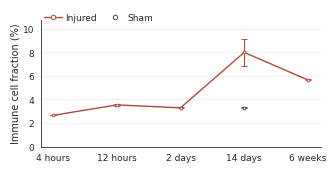

In [10]:
from matplotlib.lines import Line2D

sns.set_style("white")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 7,
    "axes.linewidth": 0.6,
    "axes.labelsize": 7,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

plot_palette = {
    "Injured": "#B24A3B",
    "Sham control": "#4A4A4A",
}

fig, ax = plt.subplots(figsize=(3.5, 2.35))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

inj = summary_df[summary_df["condition"] == "Injured"].copy()
inj = inj.sort_values("x")
yerr_inj = np.vstack([
    inj["yerr_low"].to_numpy(),
    inj["yerr_high"].to_numpy()
])

ax.errorbar(
    inj["x"],
    inj["mean_percent"],
    yerr=yerr_inj,
    fmt="-o",
    color=plot_palette["Injured"],
    markerfacecolor="white",
    markeredgecolor=plot_palette["Injured"],
    markeredgewidth=0.7,
    markersize=2,
    linewidth=1.0,
    elinewidth=0.8,
    capsize=2.4,
    capthick=0.8,
    zorder=3,
)



sham = summary_df[summary_df["condition"] == "Sham control"].copy()
yerr_sham = np.vstack([
    sham["yerr_low"].to_numpy(),
    sham["yerr_high"].to_numpy()
])

ax.errorbar(
    sham["x"],
    sham["mean_percent"],
    yerr=yerr_sham,
    fmt="o",
    color=plot_palette["Sham control"],
    markerfacecolor="white",
    markeredgecolor=plot_palette["Sham control"],
    markeredgewidth=0.7,
    markersize=2,
    linewidth=0,
    elinewidth=0.8,
    capsize=2.4,
    capthick=0.8,
    zorder=4,
)

y_max = summary_df["max_percent"].max()
ax.set_ylim(0, max(5, y_max * 1.18))
ax.set_xlabel("")
ax.set_ylabel("Immune cell fraction (%)", labelpad=2)
ax.set_xticks(range(len(time_order)))
ax.set_xticklabels(time_order)
ax.grid(axis="y", color="#E6E6E6", linewidth=0.45)
ax.grid(axis="x", visible=False)
ax.tick_params(axis="both", length=2.5, width=0.6, color="black", pad=2)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="-",
        color=plot_palette["Injured"],
        markerfacecolor="white",
        markeredgecolor=plot_palette["Injured"],
        markeredgewidth=0.7,
        linewidth=1.0,
        markersize=3.2,
        label="Injured"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=plot_palette["Sham control"],
        markerfacecolor="white",
        markeredgecolor=plot_palette["Sham control"],
        markeredgewidth=0.7,
        markersize=3.2,
        label="Sham"
    ),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(0, 1.02),
    ncol=2,
    handletextpad=0.35,
    columnspacing=1.0,
    borderaxespad=0,
)

fig.subplots_adjust(left=0.18, right=0.98, bottom=0.20, top=0.74)

plt.savefig(
    "Figures/Immune/Immune_fraction_over_time.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

In [12]:
adata.obs['region']

ShamL_1          Cortex
ShamL_2          Cortex
ShamL_3          Cortex
ShamL_4          Cortex
ShamL_5          Cortex
                  ...  
Week6R_146821    Cortex
Week6R_147127    Cortex
Week6R_147130    Cortex
Week6R_147467    Cortex
Week6R_147490    Cortex
Name: region, Length: 1374915, dtype: category
Categories (3, object): ['Cortex', 'OM', 'IM']

In [13]:
adata.var_names

Index(['AC132407.1', 'Abcc3', 'Acmsd', 'Acot7', 'Acox1', 'Acox2', 'Acsm1',
       'Acsm3', 'Acta2', 'Adamts16',
       ...
       'Vegfb', 'Vegfc', 'Vegfd', 'Vmn1r18', 'Vnn1', 'Vtn', 'Vwf', 'Wif1',
       'Wnk1', 'Wnt16'],
      dtype='object', length=299)